<a href="https://colab.research.google.com/github/siri2511/MachineLearning/blob/main/Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   devoted machine learning platform
*   tools for data mining and data analysis
*   prevalent techniques: pre-processing, classification, regression, clustering, dimensionality reduction, model selection, etc.



### **Linear Regression**
predict target value based upon the relationship between the target value and multiple (or single) independent predictor features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from sklearn.datasets import fetch_california_housing
boston = fetch_california_housing()
print(boston.data.shape)
print(boston.feature_names)
print(boston.DESCR)

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds

In [ ]:
df = pd.DataFrame(boston.data)
print(df.head(5))

        0     1         2         3       4         5      6       7
0  8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1  8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2  7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3  5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4  3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25


In [ ]:
df.columns = boston.feature_names
print(df.head(5))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
df['PRICE']=boston.target
print(df.head(5))

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
#splitting data into training and testing
X = df.drop('PRICE',axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, df.PRICE, test_size = 0.33, random_state = 42)

In [ ]:
#fitting the linear regression model
from sklearn.linear_model import LinearRegression
lm= LinearRegression()
lm.fit(X_train,Y_train)
pred_test = lm.predict(X_test)

y_test_np = np.array(Y_test)
pred_test_np = np.array(pred_test)

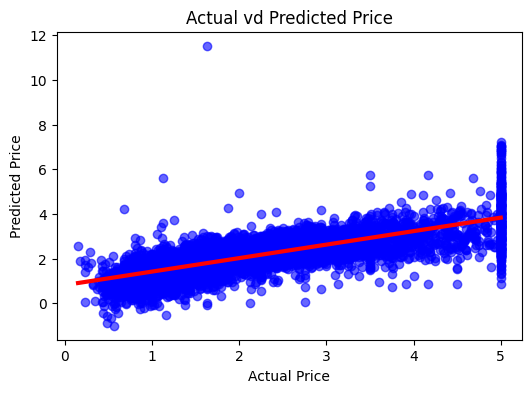

In [ ]:
# drawing scatter plot between predicted price and actual price
plt.figure(figsize=(6,4))
plt.scatter(y_test_np,pred_test_np,color='blue',alpha=0.6)

z= np.polyfit(y_test_np,pred_test_np, 1)
p = np.poly1d(z)

x_range = np.linspace(y_test_np.min(),y_test_np.max(),100)

plt.plot(x_range,p(x_range),color='red',linewidth=3)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vd Predicted Price')

plt.show()


In [ ]:
coeff_df = pd.DataFrame(X_train.columns, lm.coef_)
print(coeff_df)

mse = sklearn.metrics.mean_squared_error(Y_test, pred_test)
print(mse)

                        0
 4.448705e-01      MedInc
 9.550046e-03    HouseAge
-1.219915e-01    AveRooms
 7.791447e-01   AveBedrms
-7.689908e-08  Population
-3.299485e-03    AveOccup
-4.191312e-01    Latitude
-4.341035e-01   Longitude
0.5369686543372453


### **Exercise**
Given Airfare and Demand 2002Q4 dataset and attribute information. Build a linear regression model on the dataset to predict the price of the airfare.

In [ ]:
pip install wooldridge

In [ ]:
import wooldridge as wd

rid_data = wd.data('airfare')
print(rid_data.head())
print(rid_data.info())

   year  id  dist  passen  fare  bmktshr     ldist  y98  y99  y00     lfare  \
0  1997   1   528     152   106   0.8386  6.269096    0    0    0  4.663439   
1  1998   1   528     265   106   0.8133  6.269096    1    0    0  4.663439   
2  1999   1   528     336   113   0.8262  6.269096    0    1    0  4.727388   
3  2000   1   528     298   123   0.8612  6.269096    0    0    1  4.812184   
4  1997   2   861     282   104   0.5798  6.758094    0    0    0  4.644391   

     ldistsq  concen   lpassen  
0  39.301571  0.8386  5.023880  
1  39.301571  0.8133  5.579730  
2  39.301571  0.8262  5.817111  
3  39.301571  0.8612  5.697093  
4  45.671837  0.5798  5.641907  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     4596 non-null   int64  
 1   id       4596 non-null   int64  
 2   dist     4596 non-null   int64  
 3   passen   4596 non-null   

In [ ]:
df = pd.DataFrame(rid_data)
print(df.head(5))

   year  id  dist  passen  fare  bmktshr     ldist  y98  y99  y00     lfare  \
0  1997   1   528     152   106   0.8386  6.269096    0    0    0  4.663439   
1  1998   1   528     265   106   0.8133  6.269096    1    0    0  4.663439   
2  1999   1   528     336   113   0.8262  6.269096    0    1    0  4.727388   
3  2000   1   528     298   123   0.8612  6.269096    0    0    1  4.812184   
4  1997   2   861     282   104   0.5798  6.758094    0    0    0  4.644391   

     ldistsq  concen   lpassen  
0  39.301571  0.8386  5.023880  
1  39.301571  0.8133  5.579730  
2  39.301571  0.8262  5.817111  
3  39.301571  0.8612  5.697093  
4  45.671837  0.5798  5.641907  


In [ ]:
df.columns=rid_data.columns
print(df.head(5))

   year  id  dist  passen  fare  bmktshr     ldist  y98  y99  y00     lfare  \
0  1997   1   528     152   106   0.8386  6.269096    0    0    0  4.663439   
1  1998   1   528     265   106   0.8133  6.269096    1    0    0  4.663439   
2  1999   1   528     336   113   0.8262  6.269096    0    1    0  4.727388   
3  2000   1   528     298   123   0.8612  6.269096    0    0    1  4.812184   
4  1997   2   861     282   104   0.5798  6.758094    0    0    0  4.644391   

     ldistsq  concen   lpassen  
0  39.301571  0.8386  5.023880  
1  39.301571  0.8133  5.579730  
2  39.301571  0.8262  5.817111  
3  39.301571  0.8612  5.697093  
4  45.671837  0.5798  5.641907  


In [ ]:
df['PRICE']= rid_data.lfare
print(df.head(5))

   year  id  dist  passen  fare  bmktshr     ldist  y98  y99  y00     lfare  \
0  1997   1   528     152   106   0.8386  6.269096    0    0    0  4.663439   
1  1998   1   528     265   106   0.8133  6.269096    1    0    0  4.663439   
2  1999   1   528     336   113   0.8262  6.269096    0    1    0  4.727388   
3  2000   1   528     298   123   0.8612  6.269096    0    0    1  4.812184   
4  1997   2   861     282   104   0.5798  6.758094    0    0    0  4.644391   

     ldistsq  concen   lpassen     PRICE  
0  39.301571  0.8386  5.023880  4.663439  
1  39.301571  0.8133  5.579730  4.663439  
2  39.301571  0.8262  5.817111  4.727388  
3  39.301571  0.8612  5.697093  4.812184  
4  45.671837  0.5798  5.641907  4.644391  


In [ ]:
X = df.drop('PRICE', axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, df.PRICE, test_size = 0.33, random_state = 42)

In [ ]:
lm = LinearRegression()
lm.fit(X_train,Y_train)
pred_test = lm.predict(X_test)

y_test_np = np.array(Y_test)
pred_test_np = np.array(pred_test)

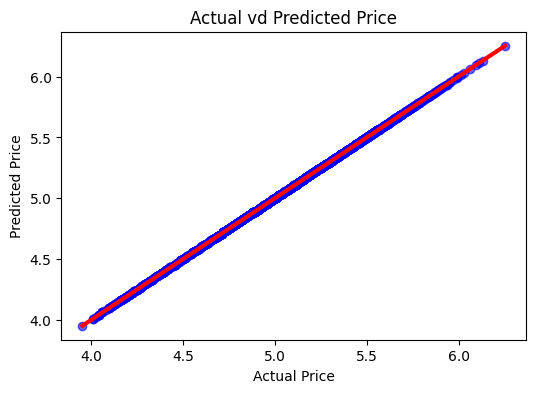

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_np,pred_test_np,color='blue',alpha=0.6)

z= np.polyfit(y_test_np,pred_test_np, 1)
p = np.poly1d(z)

x_range = np.linspace(y_test_np.min(),y_test_np.max(),100)

plt.plot(x_range,p(x_range),color='red',linewidth=3)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vd Predicted Price')

plt.show()

### **Logistic Regression**
<br>
*   used when a given target attribute is quantitative or continuous in nature<br>
*   predicting a categorical target attribute

In [ ]:
from sklearn import linear_model, datasets
iris=datasets.load_iris()
X = iris.data[:,:2]
Y = iris.target

In [ ]:
lm = linear_model.LogisticRegression(C=1e5)
lm.fit(X, Y)

LogisticRegression(C=100000.0)

In [ ]:
x_min, x_max = X[:,0].min()-.5,X[:,0].max()+.5
y_min, y_max = X[:,1].min()-.5,X[:,1].max()+.5

h=.02

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))

/tmp/ipykernel_1454/2156858464.py:7: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(4,3))


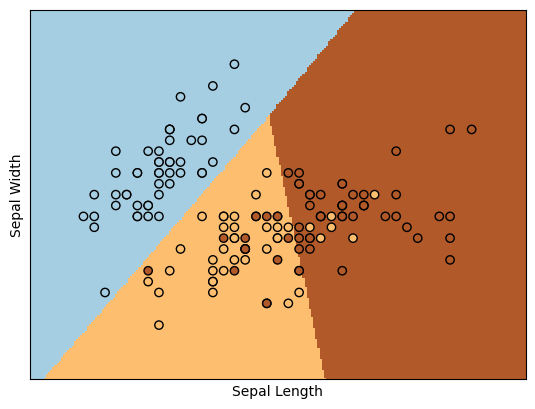

In [ ]:
Z = lm.predict(np.c_[xx.ravel(),yy.ravel()])

Z = Z.reshape(xx.shape)
plt.pcolormesh(xx,yy,Z, cmap=plt.cm.Paired)

#labeling
plt.figure(1,figsize=(4,3))
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
plt.xticks(())
plt.yticks(())
plt.scatter(X[:,0],X[:,1],c=Y,edgecolors='k',cmap=plt.cm.Paired)
plt.show()


### **Decision Tree**


*   supervised learning
*   for classification and regression models
*   goal: create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data'
columns = ['Class', 'Left-Weight', 'Left-Distance', 'Right-Weight', 'Right-Distance']
df = pd.read_csv(url, names=columns)
print(df.head(5))
print(df.info())

  Class  Left-Weight  Left-Distance  Right-Weight  Right-Distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Class           625 non-null    object
 1   Left-Weight     625 non-null    int64 
 2   Left-Distance   625 non-null    int64 
 3   Right-Weight    625 non-null    int64 
 4   Right-Distance  625 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 24.5+ KB
None


In [ ]:
X = df.values[:,1:5]
Y = df.values[:,0]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

A decision tree classifier can have two criterion i.e., Gini or Entropy

In [ ]:
# gini impurity
lm_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42, min_samples_leaf=5)
lm_gini.fit(X_train, Y_train)
y_pred = lm_gini.predict(X_test)

#information gain
lm_ig = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42, min_samples_leaf=5)
lm_ig.fit(X_train, Y_train)
y_pred_ig = lm_ig.predict(X_test)

In [ ]:
print(y_pred)
print(y_pred_ig)

['L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L'
 'R' 'R' 'R' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'L' 'R' 'L'
 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'R' 'R' 'L' 'R' 'R'
 'R' 'R' 'R' 'L' 'L' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L'
 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R'
 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'R'
 'L' 'R' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'R' 'R'
 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'R'
 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'L' 'L' 'L' 'L' 'R' 'L'
 'R' 'R' 'L' 'R' 'L' 'R' 'R' 'L']
['L' 'L' 'R' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L'
 'R' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'R' 'L'
 'L' 'L' 'R' 'L' 

In [ ]:
print('Accuracy of Gini Impurity model: ', accuracy_score(Y_test,y_pred)*100)
print('Accuracy of Information Gain model: ',accuracy_score(Y_test,y_pred_ig)*100)

Accuracy of Gini Impurity model:  70.2127659574468
Accuracy of Information Gain model:  68.08510638297872


### **K-Means Clustering**


*   task of grouping a set of objects in such a way that objects in the same group (called a cluster) are more similar to each other than to those in other groups
*   clusters data by trying to separate sampels in n groups of equal variance, minimizing a criterion known as the inertia or within-cluster sum of square



In [ ]:
np.random.seed(42)
n=20
data={
    'Driver_ID':np.random.randint(3423310000,3423320000,n),
    "Distance_Feature":np.round(np.random.uniform(30,80,n),2),
    "Speeding_Feature":np.round(np.random.uniform(5,50,n),1)
}

df = pd.DataFrame(data)
print(df.head(5))

    Driver_ID  Distance_Feature  Speeding_Feature
0  3423317270             56.24               9.4
1  3423310860             51.60              35.8
2  3423315390             44.56              24.8
3  3423315191             60.59              10.5
4  3423315734             36.97              27.3


In [ ]:
f1 = df['Distance_Feature'].values
f2 = df['Speeding_Feature'].values

X=pd.DataFrame({'dist':f1,'speed':f2})

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans=KMeans(n_clusters=2)
k_fit = kmeans.fit(X)
pred = kmeans.predict(X)

In [ ]:
centroids = kmeans.cluster_centers_
print(centroids)

[[45.92222222 15.15555556]
 [58.43727273 39.45454545]]


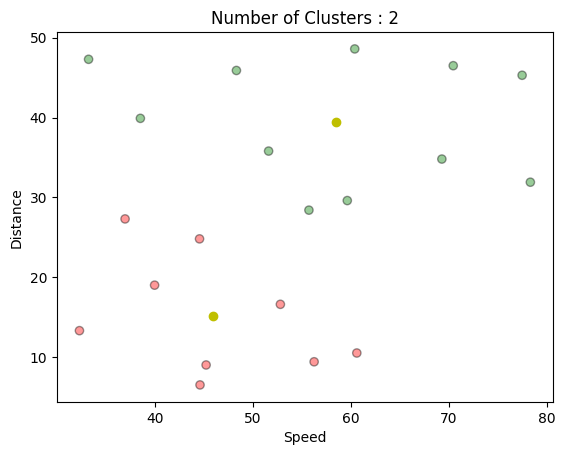

In [ ]:
colmap={1:'r',2:'g',3:'b',4:'k'}
colors = list(map(lambda x: colmap[x+1],pred))

plt.scatter(f1,f2,color=colors, alpha=0.4,edgecolor='k')
plt.scatter(centroids[:,0],centroids[:,1],color='y')
plt.xlabel('Speed')
plt.ylabel('Distance')
plt.title('Number of Clusters : 2')
plt.show()

### **Exercise**

<br>
Import the iris modified dataset & perform the following operations:
<br>

1.   Find 3 clusters in the dataset
2.   Find the size of each cluster
3.   Visualize the clusters using the matplotlib library



In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris =load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)

df.columns=['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']

df = df[['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']]

print(df.head())

   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster']=kmeans.fit_predict(df)

In [ ]:
cluster_sizes = df['Cluster'].value_counts()

print(cluster_sizes)

Cluster
2    61
1    50
0    39
Name: count, dtype: int64


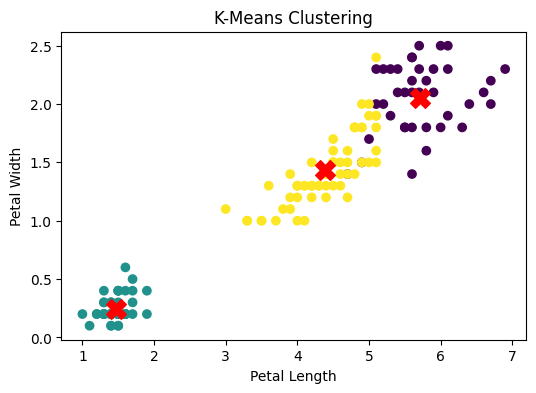

In [ ]:
plt.figure(figsize=(6,4))

#scatter plot
plt.scatter(df['Petal.Length'],df['Petal.Width'],c=df['Cluster'],cmap='viridis')

#plot centroids
centers=kmeans.cluster_centers_

plt.scatter(centers[:,2],centers[:,3],color='red',marker='X',s=200)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering')
plt.show()